# Mapping the Parameter Space of $n_s$ and $r$

This notebook uses the `numerical_observables_calculation` pipeline to explore how initial field configurations $(\phi_i, y_i)$ affect the observed primordial power spectrum. 

We will:
1. Define a grid of initial conditions.
2. Run the exact numerical solver for each point.
3. Visualize the results using heatmaps (how $n_s$ varies) and trajectory plots in the $n_s$ vs $r$ plane.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
import os
from tqdm.notebook import tqdm
import json
import uuid
import datetime

# Import our new pipeline and model
sys.path.append(os.path.abspath('..'))
from inflation_models import HiggsModel
import numerical_observables_calculation as calc

# Setup Plotting
plt.style.use('seaborn-v0_8-paper')
sns.set_context("talk")
params = {'legend.fontsize': 'medium',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'medium',
         'ytick.labelsize':'medium'}
plt.rcParams.update(params)
sns.set_palette("viridis")

## 1. Grid Definition
We explore a range of initial values around the standard USR (Ultra Slow Roll) transition points for Higgs Inflation.

In [2]:
model = HiggsModel(xi=1000, lam=0.13)

# Define Grid
phi0_vals = np.linspace(5.5, 5.6, 50) 
yi_vals = np.linspace(-0.15, -0.05, 50)

all_results = []

print(f"Starting grid search on {len(phi0_vals) * len(yi_vals)} configurations...")

for p in tqdm(phi0_vals, desc="Phi0 Index"):
    for v in yi_vals:
        custom_T_span = np.linspace(0, 1000, 10000)
        res = calc.run_inflation_protocol(model, phi0=p, yi=v, delta=1e-5, T_span_bg=custom_T_span)

        
        if res["status"] == "success":
            all_results.append({
                'phi0': p,
                'yi': v,
                'ns': res['ns'],
                'r': res['r'],
                'ns_SR': res['ns_SR'],
                'r_SR': res['r_SR'],
                'N_total': res['N_total'],
                'Ps': res['P_S']
            })


df = pd.DataFrame(all_results)
print("Grid search complete!")

Starting grid search on 2500 configurations...


Phi0 Index:   0%|          | 0/50 [00:00<?, ?it/s]

Grid search complete!


In [36]:


# 1. Extract bounds for the metadata and filename
phi0_min = min(phi0_vals)
phi0_max = max(phi0_vals)
yi_min = min(yi_vals)
yi_max = max(yi_vals)


# 2. Build the structured JSON dictionary dynamically
grid_output_data = {
    "metadata": {
        "run_id": uuid.uuid4().hex[:8],
        "timestamp": datetime.datetime.now().isoformat(),
        "description": "Grid search mapping ns and r sensitivity to initial conditions."
    },
    "model_parameters": {
        "name": "Higgs Inflation",
        # DYNAMIC EXTRACTION from your instantiated model object
        "xi": model.xi_val,
        "lambda": model.lam
    },
    "grid_parameters": {
        "phi0_min": phi0_min,
        "phi0_max": phi0_max,
        "phi0_steps": len(phi0_vals),
        "yi_min": yi_min,
        "yi_max": yi_max,
        "yi_steps": len(yi_vals),
        "total_configurations_attempted": len(phi0_vals) * len(yi_vals),
        "successful_simulations": len(all_results)
    }}



# 3. Create the save path and directory
save_dir = '../outputs'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 4. Generate a descriptive filename with bounds and run_id
filename = f"grid_search_phi0_{phi0_min:.2f}to{phi0_max:.2f}_yi_{abs(yi_min):.2f}to{abs(yi_max):.2f}_{grid_output_data['metadata']['run_id']}.json"
filepath = os.path.join(save_dir, filename)

# 5. Write the data to a JSON file
with open(filepath, 'w') as f:
    json.dump(grid_output_data, f, indent=4)

print(f"✅ Grid search results securely saved to: {filepath}")


✅ Grid search results securely saved to: ../outputs\grid_search_phi0_5.50to5.60_yi_0.15to0.05_049faa37.json


In [ ]:
file_to_load = "../outputs/grid_search_phi0_5.50to5.60_yi_0.15to0.05_c73f6541.json"

if not os.path.exists(file_to_load):
    print(f"Error: Could not find file at {file_to_load}")
else:
    # 2. Read the JSON file
    with open(file_to_load, 'r') as f:
        loaded_data = json.load(f)
    
    # 3. Reconstruct the DataFrame INSTANTLY from the "results" list
    df_loaded = pd.DataFrame(loaded_data["results"])
    
    # 4. Print out helpful metadata to remind you what this run was exactly
    meta = loaded_data["metadata"]
    model_params = loaded_data["model_parameters"]
    grid_params = loaded_data["grid_parameters"]
    
    print("-" * 50)
    print(f"✅ Loaded Run ID : {meta['run_id']}")
    print(f"📅 Timestamp     : {meta['timestamp'][:19]}") # cuts off ms precision
    print(f"🧠 Model Specs   : {model_params['name']} (xi={model_params['xi']}, lambda={model_params['lambda']})")
    print(f"📏 Grid Status   : {grid_params['successful_simulations']} / {grid_params['total_configurations_attempted']} points succeeded.")
    print("-" * 50)
    
    # Preview the recovered DataFrame
    display(df_loaded.head())


## 2. Visualizing how $n_s$ moves in the Initial Condition Plane

We use heatmaps to see where the field configuration leads to higher or lower spectral indices.

<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
C:\Users\diego\AppData\Local\Temp\ipykernel_23204\1723524190.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Initial Field $\phi_0$")


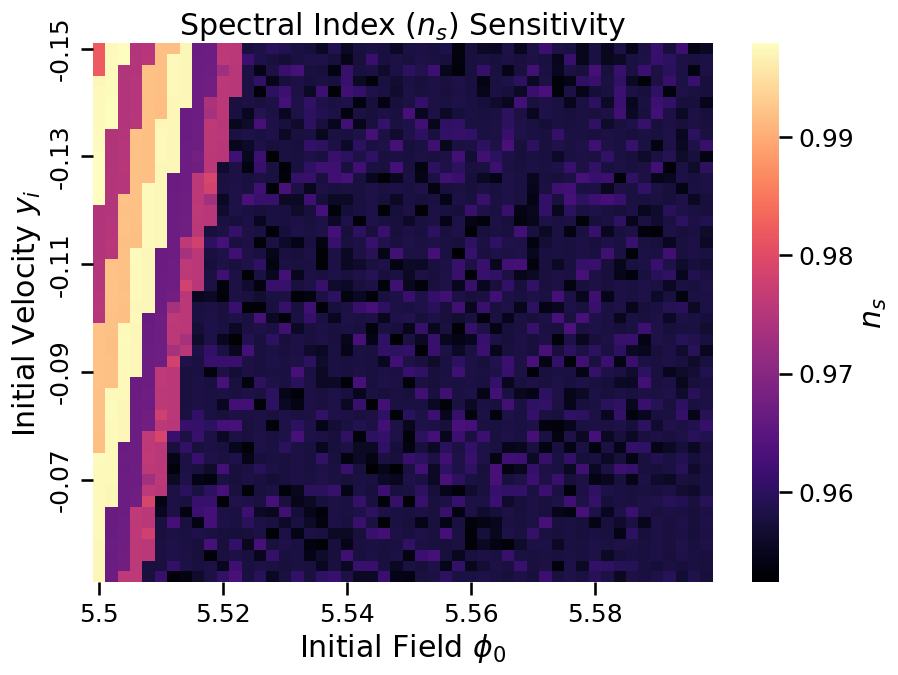

In [15]:
plt.figure(figsize=(10, 7))

# Round the labels for display
plot_df = pivot_df.copy()
plot_df.index = [np.round(y, 2) for y in plot_df.index]
plot_df.columns = [np.round(x, 2) for x in plot_df.columns]

# Show every 10th label (5 ticks for 50 data points)
ax = sns.heatmap(plot_df, 
                 cmap="magma",
                 xticklabels=10, 
                 yticklabels=10,
                 cbar_kws={'label': '$n_s$'})

plt.title("Spectral Index ($n_s$) Sensitivity")
plt.xlabel("Initial Field $\phi_0$")
plt.ylabel("Initial Velocity $y_i$")
plt.show()


--- Statistical Analysis of n_s: Exact MS vs Slow-Roll ---
Mean Absolute Error (MAE): 1.038e-02
Root Mean Square Error (RMSE): 1.177e-02
Max Absolute Error:        3.034e-02
Average Variance (%):      1.07310%
--------------------------------------------------------


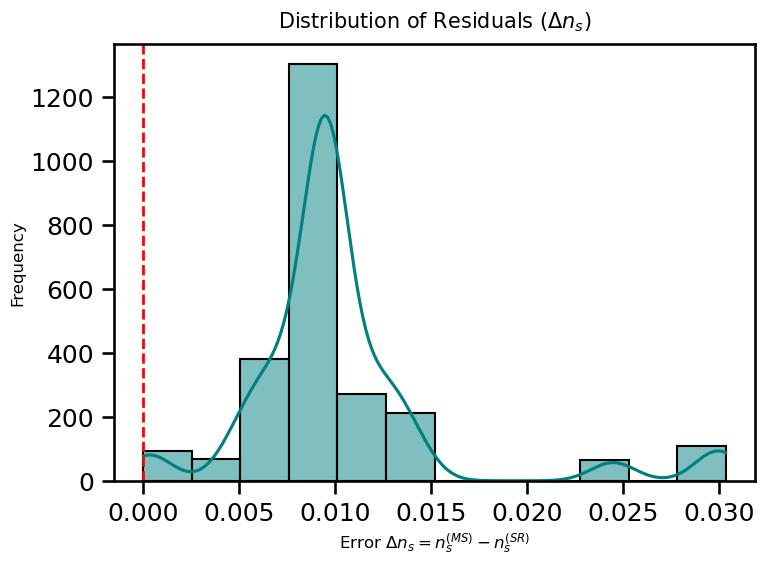

In [4]:
# 1. Calculate the Error / Residuals
df['delta_ns'] = np.abs(df['ns'] - df['ns_SR'])
df['abs_error_ns'] = df['delta_ns'].abs()
df['pct_error_ns'] = (df['abs_error_ns'] / df['ns_SR']) * 100

# 2. Print Key Statistical Metrics
mae = df['abs_error_ns'].mean()
max_err = df['abs_error_ns'].max()
rmse = np.sqrt((df['delta_ns']**2).mean())

print(f"--- Statistical Analysis of n_s: Exact MS vs Slow-Roll ---")
print(f"Mean Absolute Error (MAE): {mae:.3e}")
print(f"Root Mean Square Error (RMSE): {rmse:.3e}")
print(f"Max Absolute Error:        {max_err:.3e}")
print(f"Average Variance (%):      {df['pct_error_ns'].mean():.5f}%")
print("-" * 56)

# =========================================================
# GRAPH 1: Distribution of Residuals (Delta ns)
# =========================================================
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='delta_ns', kde=True, color='teal', bins=12, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.title("Distribution of Residuals ($\\Delta n_s$)", fontsize=15, pad=12)
plt.xlabel("Error $\\Delta n_s = n_s^{(MS)} - n_s^{(SR)}$", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()




<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
C:\Users\diego\AppData\Local\Temp\ipykernel_23204\486829323.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("Initial Field $\phi_0$", fontsize=13)
C:\Users\diego\AppData\Local\Temp\ipykernel_23204\486829323.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12, loc='upper right')


Professional plot saved dynamically as: plots/ns_MSvSR_yi_-0.15_phi0_5.50to5.60.pdf


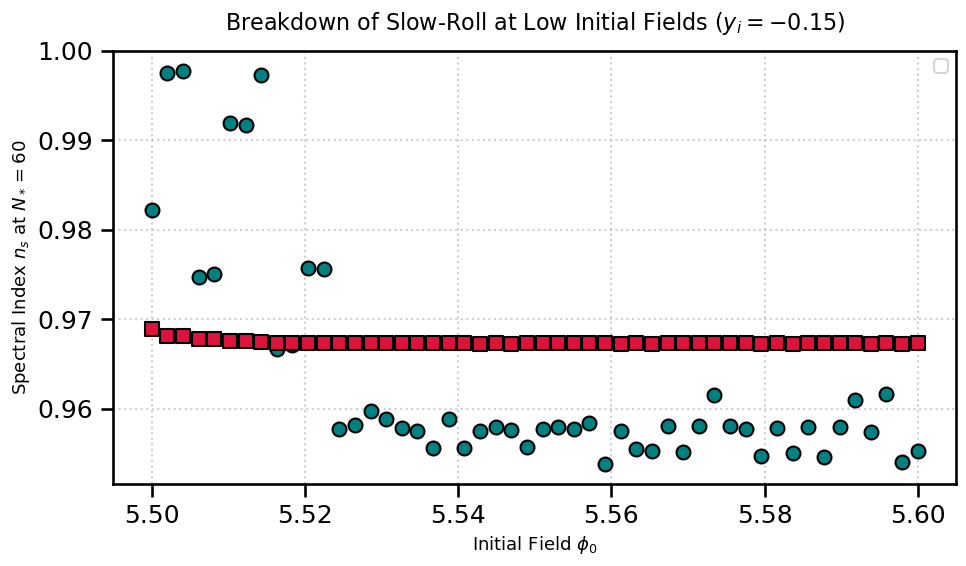

In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline


target_yi = -0.15 

# Use np.isclose to prevent floating-point precision errors (like -0.1499999 != -0.15)
df_slice = df[np.isclose(df['yi'], target_yi)].sort_values('phi0')

if df_slice.empty:
    print(f"Warning: No data found for yi = {target_yi}. Please check your grid.")
else:
    x_raw = df_slice['phi0']
    y_ms_raw = df_slice['ns']
    y_sr_raw = df_slice['ns_SR']

    x_smooth = np.linspace(x_raw.min(), x_raw.max(), 300)

    spline_ms = make_interp_spline(x_raw, y_ms_raw, k=3)
    spline_sr = make_interp_spline(x_raw, y_sr_raw, k=3)

    y_ms_smooth = spline_ms(x_smooth)
    y_sr_smooth = spline_sr(x_smooth)


    plt.figure(figsize=(10, 6))

    # Scatter points for exact raw data
    plt.scatter(x_raw, y_ms_raw, color='teal', s=100, marker='o', zorder=5, edgecolor='black')
    plt.scatter(x_raw, y_sr_raw, color='crimson', s=100, marker='s', zorder=5, edgecolor='black')

    # Connecting smoothed splines and fill buffer
    #plt.plot(x_smooth, y_ms_smooth, linestyle='-', linewidth=2.5, color='teal', label='MS ($n_s$)', zorder=2)
    #plt.plot(x_smooth, y_sr_smooth, linestyle='--', linewidth=2.5, color='crimson', label='Slow-Roll ($n_s^{(SR)}$)', zorder=2)
    #plt.fill_between(x_smooth, y_ms_smooth, y_sr_smooth, color='gray', alpha=0.15, label='$\Delta n_s$ Residual')

    # Automatically format title with current target
    plt.title(f"Breakdown of Slow-Roll at Low Initial Fields ($y_i = {target_yi}$)", fontsize=16, pad=15)
    plt.xlabel("Initial Field $\phi_0$", fontsize=13)
    plt.ylabel("Spectral Index $n_s$ at $N_*=60$", fontsize=13)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=12, loc='upper right')

    plt.tight_layout()

    # ---------------------------------------------------------
    # 4. DYNAMIC FILE SAVING
    # ---------------------------------------------------------
    # Generate filename dynamically from the bounds
    filename = f"ns_MSvSR_yi_{target_yi:.2f}_phi0_{x_raw.min():.2f}to{x_raw.max():.2f}"
    
    # Ensure plots directory exists
    if not os.path.exists('plots'):
        os.makedirs('plots')
        
    plt.savefig(f"../images/{filename}.png", bbox_inches='tight', dpi=300)
    
    print(f"Professional plot saved dynamically as: plots/{filename}.pdf")

    # Finally, show the plot
    plt.show()
